# Lecture 7.1: The Forecaster's Toolbox (Part 2)

*DASCI 270 - Time Series Analysis*

*Prepared by Sebastian C. Ibañez, PhD*

*Based on [FPPY Chapter 5](https://otexts.com/fpppy/nbs/05-toolbox.html)*

`And if anyone takes away from the words of the book of this prophecy, God will take away his share in the tree of life and in the holy city, which are described in this book. -Revelation 22:19`

In [1]:
%%capture
!pip install statsforecast
!pip install utilsforecast

!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_production_formatted.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/gafa_stock.csv' -P ./data/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    RandomWalkWithDrift,
    HistoricAverage,
)

plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

pd.set_option("display.precision", 3)
np.set_printoptions(suppress=True)

## Forecasting horizon

Before we begin forecasting, we need to make sure that our objective is well defined.

Often, the business problem will dictate how we build our forecasting methodology and its accompanying evaluation strategy.

Is our goal to perform *one-step* or *multi-step* forecasting?

1. One-step forecasting refers to making a prediction for the next time step.

2. Multi-step forecasting refers to making predictions for the next $h$ time steps. We will refer to $h$ as the **prediction horizon** or **forecast horizon**.

## Evaluating point forecast accuracy

### Training and test sets

When evaluating model performance, it is common practice to separate the data into two partitions: the training and test sets.

<img src="https://otexts.com/fpppy/nbs/05-toolbox_files/figure-html/fig-train_test_split-output-1.png" width="100%">

For time series data, a single train-test split would look something like the figure shown above.

Unlike other prediction problems, the sequential nature of time series data introduces a unique set of challenges that should be taken to account by the modeler.

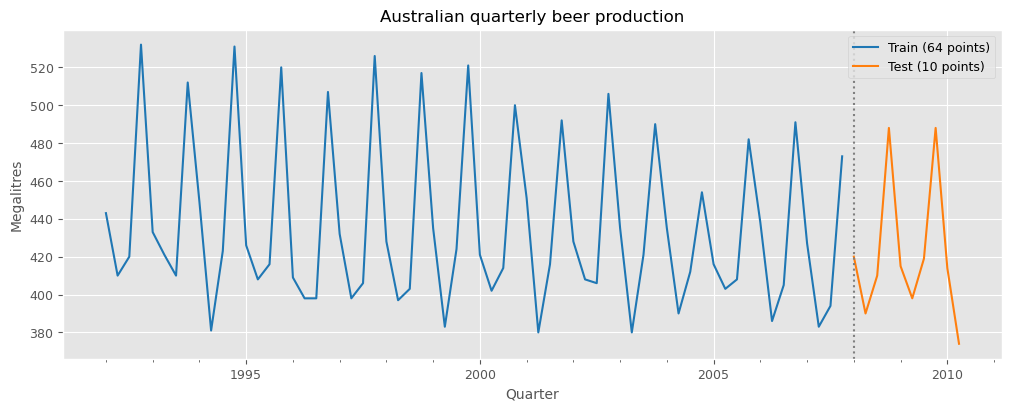

In [4]:
df_prod = pd.read_csv("data/aus_production_formatted.csv", parse_dates=["ds"])
df_prod["ds"] = df_prod["ds"].dt.to_period('Q').dt.to_timestamp() # fix dates to QS
df_beer = df_prod[df_prod["unique_id"] == "Beer"]
df_beer = df_beer[df_beer["ds"] >= "1992-01-01"]

# Single train-test split!
df_train = df_beer.query("ds.dt.year <= 2007")
df_test = df_beer.query("ds.dt.year > 2007")

fig, ax = plt.subplots()
df_train.plot(ax=ax, x='ds', y='y', color='tab:blue', legend=False)
df_test.plot(ax=ax, x='ds', y='y', color='tab:orange', legend=False)
ax.set_title("Australian quarterly beer production")
ax.set_xlabel("Quarter")
ax.set_ylabel("Megalitres")
plt.axvline(x=df_test['ds'].iloc[0], color='grey', linestyle='dotted')
plt.legend([f'Train ({len(df_train)} points)', f'Test ({len(df_test)} points)'])
plt.autoscale()
plt.show()

### Forecast errors

**Forecast errors** are the difference between an observed value and its forecast:

\begin{align*}
  e_{T+h} &= y_{T+h} - \hat{y}_{T+h|T}
\end{align*}

where the training data is given by $\{y_1, y_2, \ldots, y_T \} $ and the test data is given by $\{y_{T+1}, y_{T+2}, y_{T+3}, \ldots \} $.

We can measure forecast accuracy by summarizing the forecast errors in different ways.

In [5]:
sf = StatsForecast(
    models=[RandomWalkWithDrift(), HistoricAverage(), Naive(), SeasonalNaive(4)], # 4 baseline methods
    freq="QS"
)

df_f = sf.forecast(h=len(df_test), df=df_train) # h=10
df_f = pd.merge(df_test, df_f, on=['ds', 'unique_id']) # append ground truth "y"
df_f

,unique_id,ds,y,RWD,HistoricAverage,Naive,SeasonalNaive
0,Beer,2008-01-01,420.0,473.476,435.375,473.0,427.0
1,Beer,2008-04-01,390.0,473.952,435.375,473.0,383.0
2,Beer,2008-07-01,410.0,474.429,435.375,473.0,394.0
3,Beer,2008-10-01,488.0,474.905,435.375,473.0,473.0
4,Beer,2009-01-01,415.0,475.381,435.375,473.0,427.0
5,Beer,2009-04-01,398.0,475.857,435.375,473.0,383.0
6,Beer,2009-07-01,419.0,476.333,435.375,473.0,394.0
7,Beer,2009-10-01,488.0,476.810,435.375,473.0,473.0
8,Beer,2010-01-01,414.0,477.286,435.375,473.0,427.0
9,Beer,2010-04-01,374.0,477.762,435.375,473.0,383.0


In [6]:
# raw errors
pd.DataFrame({
    "e_RWD": df_f["y"] - df_f["RWD"],
    "e_HistoricAverage": df_f["y"] - df_f["HistoricAverage"],
    "e_Naive": df_f["y"] - df_f["Naive"],
    "e_SeasonalNaive": df_f["y"] - df_f["SeasonalNaive"],
})

,e_RWD,e_HistoricAverage,e_Naive,e_SeasonalNaive
0,-53.476,-15.375,-53.0,-7.0
1,-83.952,-45.375,-83.0,7.0
2,-64.429,-25.375,-63.0,16.0
3,13.095,52.625,15.0,15.0
4,-60.381,-20.375,-58.0,-12.0
5,-77.857,-37.375,-75.0,15.0
6,-57.333,-16.375,-54.0,25.0
7,11.190,52.625,15.0,15.0
8,-63.286,-21.375,-59.0,-13.0
9,-103.762,-61.375,-99.0,-9.0


### Scale-dependent errors

**Scale-dependent errors** are forecast errors that are on the same scale as the data. Accuracy measures that are based only on $e_t = y_t - \hat{y}_t$ are therefore scale dependent and cannot be used to make comparisons between series that involve different units.

The two most commonly used scale-dependent measures are the **mean absolute error** (MAE) and the **root mean squared error** (RMSE):

\begin{align*}
    \text{MAE} &= \frac{1}{n} \sum_{t=1}^{n} |y_t - \hat{y}_t| \\
    \text{RMSE} &= \sqrt{\frac{1}{n} \sum_{t=1}^{n} (y_t - \hat{y}_t)^2}
\end{align*}

where $n$ is the number of observations in the test set.

When comparing forecast methods applied to a single time series, or to several time series with the same units, the MAE is popular as it is easy to both understand and compute. A forecast method that minimises the MAE will lead to forecasts of the median, while minimising the RMSE will lead to forecasts of the mean. Consequently, the RMSE is also widely used, despite being more difficult to interpret.

### Percentage errors

**Percentage errors** have the advantage of being unit-free, and so are frequently used to compare forecast performances between data sets.

Two commonly used percentage-based measures are the **mean absolute percentage error** (MAPE) and the **symmetric mean absolute percentage error** (sMAPE):

\begin{align*}
    \text{MAPE} &= \frac{100}{n} \sum_{t=1}^{n} \bigg|\frac{y_t - \hat{y}_t}{y_t}\bigg| \\
    \text{sMAPE} &= \frac{100}{n} \sum_{t=1}^{n} \frac{2|y_t - \hat{y}_t|}{|y_t| + |\hat{y}_t|}
\end{align*}

where $n$ is the number of observations in the test set.

Some problems with MAPE:
- Can be infinite or undefined if $y_t = 0$ in the period of interest, and having extreme values if any $y_t$ is close to zero.
- Assumes that the unit of measurement has a meaningful zero. For example, a percentage error makes no sense when measuring the accuracy of temperature forecasts on either the Fahrenheit or Celsius scales, because temperature has an arbitrary zero point.
- MAPE has a specific disadvantage where it puts a heavier penalty on negative errors than on positive errors. Thus, sMAPE was "proposed" as a solution to this drawback. Whether or not this is an actual problem is typically use case specific.

Some problems with sMAPE:
- sMAPE is not symmetric with respect to under- or over-forecasting.
- Doesn't really make sense, see [here](https://robjhyndman.com/hyndsight/smape/) for a more in-depth discussion. Essentially, it makes "corrections" to the original MAPE that destroy its main advantage: being an *interpretable percentage error*.

The authors of the textbook discourage the use of sMAPE but is included here because it is widely used.

#### Example - MAPE explodes

In [7]:
def my_mape(a, f):
  return np.abs(100*(a - f)/a)

def my_smape(a, f):
  return 200*np.abs(a - f)/(np.abs(a) + np.abs(f))

In [9]:
a = 0.01  # actual
f1 = 0.5  # forecast 1
f2 = -0.5 # forecast 2

print(f" MAPE: {my_mape(a, f1):.2f}, {my_mape(a, f2):.2f}") # when y_t is close to 0, MAPE explodes
print(f"sMAPE: {my_smape(a, f1):.2f}, {my_smape(a, f2):.2f}")

 MAPE: 4900.00, 5100.00
sMAPE: 192.16, 200.00


#### Example - MAPE is not "symmetric"

\begin{align*}
    \text{MAPE}(x, y) &\neq \text{MAPE}(y, x) \\
    \text{sMAPE}(x, y) &= \text{sMAPE}(y, x)
\end{align*}

In [10]:
print(f"MAPE(100, 110): {my_mape(100, 110):.2f}")
print(f"MAPE(110, 100): {my_mape(110, 100):.2f}")

MAPE(100, 110): 10.00
MAPE(110, 100): 9.09


In [11]:
print(f"sMAPE(100, 110): {my_smape(100, 110):.2f}")
print(f"sMAPE(110, 100): {my_smape(110, 100):.2f}")

sMAPE(100, 110): 9.52
sMAPE(110, 100): 9.52


#### Example - sMAPE is not "symmetric wrt sign"

In [ ]:
a = 100  # actual
f1 = 110 # forecast 1, +10 from true
f2 = 90  # forecast 2, -10 from true

def my_mape(a, f):
  return np.abs((a - f)/a)*100

def my_smape(a, f):
  return np.abs(a - f)/(np.abs(a) + np.abs(f))*100

print(f" MAPE: {my_mape(a, f1):.2f}, {my_mape(a, f2):.2f}")
print(f"sMAPE: {my_smape(a, f1):.2f}, {my_smape(a, f2):.2f}") # not symmetric with respect to sign of error term

 MAPE: 10.00, 10.00
sMAPE: 4.76, 5.26


### Scaled errors

**Scaled errors** were proposed by [Hyndman & Koehler (2006)](https://www.sciencedirect.com/science/article/abs/pii/S0169207006000239) as an alternative to using percentage errors when comparing forecast accuracy across series with different units.

One can scale the errors based on the *training* MAE or RMSE (i.e., in-sample errors) from a simple forecast method, typically the Naive or Seasonal Naive method.

In this case, we call these measures **mean absolute scaled errors** (MASE) or **root mean squared scale error** (RMSSE).

For non-seasonal time series, we use the in-sample Naive MAE/RMSE as the scaler:

\begin{align*}
    \text{MASE} &= \frac{1}{n} \sum_{t=1}^{n} \left|\frac{y_t - \hat{y}_t}{\frac{1}{T-1}\sum_{i=2}^{T}\left|y_i - y_{i-1}\right|}\right|
\end{align*}

\begin{align*}
    \text{RMSSE} &= \sqrt{\frac{1}{n} \sum_{t=1}^{n} \frac{(y_t - \hat{y}_t)^2}{\frac{1}{T-1}\sum_{i=2}^{T}(y_i - y_{i-1})^2}}
\end{align*}

where $T$ and $n$ are the number of observations in the training set and test set, respectively.

### Example: Australian quarterly beer production (multi-step)

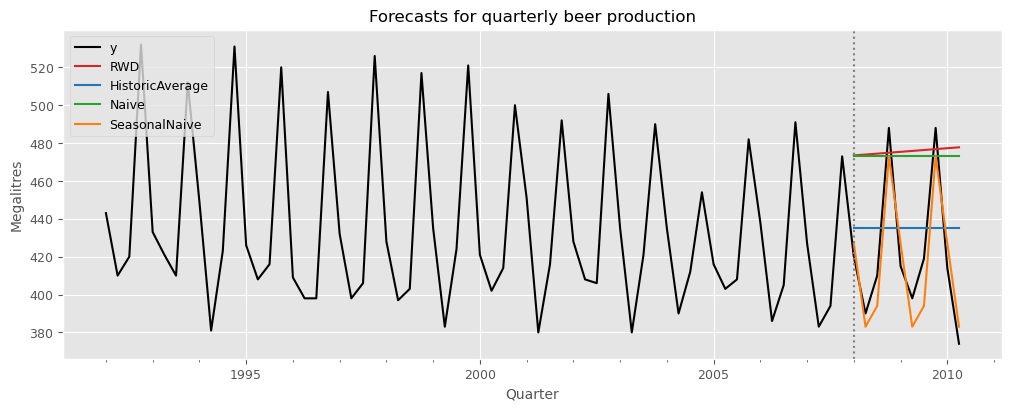

In [14]:
fig, ax = plt.subplots()
df_beer.plot(ax=ax, x='ds', y='y', color='black')
df_f.plot(ax=ax, x='ds', y=['RWD', 'HistoricAverage', 'Naive', 'SeasonalNaive'], color=['tab:red', 'tab:blue', 'tab:green', 'tab:orange'])
ax.set_title("Forecasts for quarterly beer production")
ax.set_xlabel("Quarter")
ax.set_ylabel("Megalitres")
plt.axvline(x=df_f['ds'].iloc[0], color='grey', linestyle='dotted')
plt.autoscale()
plt.show()

In [17]:
from functools import partial
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape as _mape, mase, rmsse

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include='number').columns] *= 100
    return df_mape

df_eval = evaluate(df_f, metrics=[rmse, mae, mape, partial(mase, seasonality=4), partial(rmsse, seasonality=4)], train_df=df_train) # mase uses snaive as scaler
df_eval.set_index('metric').T.drop('unique_id').sort_values(by='mae')

metric,rmse,mae,mape,mase,rmsse
SeasonalNaive,14.311,13.4,3.169,0.937,0.853
HistoricAverage,38.447,34.825,8.283,2.435,2.291
Naive,62.693,57.4,14.184,4.014,3.736
RWD,64.901,58.876,14.577,4.117,3.867


### Example: Google's daily closing stock price (multi-step)

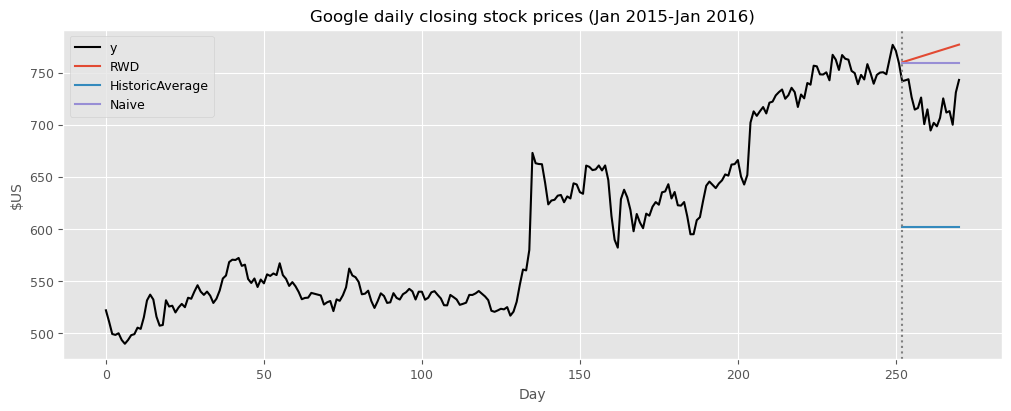

In [18]:
df_gafa = pd.read_csv("data/gafa_stock.csv", parse_dates=["ds"])
df_goog = df_gafa.query("unique_id == 'GOOG_Close' and '2015-01-01' <= ds <= '2016-01-31'")
df_goog = df_goog.reset_index(drop=True)
df_train = df_goog.query("ds.dt.year == 2015").copy()
df_test = df_goog.query("ds.dt.year == 2016").copy()
df_train["ds"] = np.arange(len(df_train["ds"]))
df_test["ds"] = np.arange(len(df_test["ds"]))

sf = StatsForecast(models=[RandomWalkWithDrift(), HistoricAverage(), Naive()], freq=1)
df_f = sf.forecast(h=len(df_test), df=df_train)

fig, ax = plt.subplots()
df_goog.plot(ax=ax, y='y', color='black')
df_f.plot(ax=ax, x='ds')
ax.set_title("Google daily closing stock prices (Jan 2015-Jan 2016)")
ax.set_xlabel("Day")
ax.set_ylabel("$US")
plt.axvline(x=df_f['ds'].iloc[0], color='grey', linestyle='dotted')
plt.autoscale()
plt.show()

In [19]:
df_f['y'] = df_test['y'].values # append ground truth "y"

df_eval = evaluate(df_f, metrics=[rmse, mae, mape, partial(mase, seasonality=1), partial(rmsse, seasonality=1)], train_df=df_train) # mase uses snaive as scaler
df_eval.set_index('metric').T.drop('unique_id')

metric,rmse,mae,mape,mase,rmsse
RWD,53.07,49.824,6.992,6.99,4.743
HistoricAverage,118.032,116.945,16.235,16.406,10.548
Naive,43.432,40.384,5.673,5.666,3.881


## Time series cross-validation

A more advance version of resampling that is applicable for time series data is **time series cross-validation** (TSCV). This is also sometimes called rolling or walk-forward validation.

Essentially, the method involves constructing a series of training and test splits such that the training set only consists of observations that occurred prior to the first observation in the test set.

<img src="https://otexts.com/fpppy/nbs/05-toolbox_files/figure-html/fig-timeseries_cv-output-1.png">

For illustration, the diagram above shows a series of training and test sets (blue and red, respectively) for a one-step forecasting problem. The sampling distribution of our metrics can then be empirically estimated by iteratively calculating the error statistic over all the test sets.

TSCV can also be used for multi-step forecasts. For example, the diagram below illustrates a 4-step-ahead TSCV split.

<img src="https://otexts.com/fpppy/nbs/05-toolbox_files/figure-html/fig-timeseries_cv_multistep-output-1.png">

This is what it looks like when we "roll-in" data by windows/chunks rather than one-step at a time:

<img src="https://raw.githubusercontent.com/Nixtla/statsforecast/main/nbs/imgs/ChainedWindows.gif">

### Example: Daily stock forecasting (one-step)

What is the best forecasting method for daily stock forecasting? Ideally, we want a method that *generalizes* well over time.

In [23]:
df_goog = df_gafa.query("unique_id == 'GOOG_Close' and '2015-01-01' <= ds <= '2016-01-31'")
df_goog = df_goog.reset_index(drop=True)
df_goog["ds"] = np.arange(len(df_goog["ds"]))
df_goog

,unique_id,ds,y
0,GOOG_Close,0,521.938
1,GOOG_Close,1,511.058
2,GOOG_Close,2,499.213
3,GOOG_Close,3,498.358
4,GOOG_Close,4,499.929
...,...,...,...
266,GOOG_Close,266,711.670
267,GOOG_Close,267,713.040
268,GOOG_Close,268,699.990
269,GOOG_Close,269,730.960


In [24]:
sf = StatsForecast(models=[RandomWalkWithDrift(), Naive()], freq=1)
df_cv = sf.cross_validation(h=1, df=df_goog, step_size=1, test_size=250) # fit_predict/forecast!

In [25]:
df_eval = evaluate(df_cv.drop('cutoff', axis=1), metrics=[mae, rmse, mape])
df_eval.set_index('metric').T.drop('unique_id')

metric,mae,rmse,mape
RWD,7.53,11.618,1.198
Naive,7.489,11.608,1.19


### Example: Quarterly beer forecasting (multi-step)

In [26]:
df_beer

,unique_id,ds,y
144,Beer,1992-01-01,443.0
145,Beer,1992-04-01,410.0
146,Beer,1992-07-01,420.0
147,Beer,1992-10-01,532.0
148,Beer,1993-01-01,433.0
...,...,...,...
213,Beer,2009-04-01,398.0
214,Beer,2009-07-01,419.0
215,Beer,2009-10-01,488.0
216,Beer,2010-01-01,414.0


In [27]:
sf = StatsForecast(models=[SeasonalNaive(4), Naive()], freq='QS')
df_cv = sf.cross_validation(h=4, df=df_beer, step_size=1, test_size=4*3)
df_cv.tail()

,unique_id,ds,cutoff,y,SeasonalNaive,Naive
31,Beer,2010-01-01,2009-01-01,414.0,415.0,415.0
32,Beer,2009-07-01,2009-04-01,419.0,410.0,398.0
33,Beer,2009-10-01,2009-04-01,488.0,488.0,398.0
34,Beer,2010-01-01,2009-04-01,414.0,415.0,398.0
35,Beer,2010-04-01,2009-04-01,374.0,398.0,398.0


In [30]:
df_cv

,unique_id,ds,cutoff,y,SeasonalNaive,Naive
0,Beer,2007-07-01,2007-04-01,394.0,405.0,383.0
1,Beer,2007-10-01,2007-04-01,473.0,491.0,383.0
2,Beer,2008-01-01,2007-04-01,420.0,427.0,383.0
3,Beer,2008-04-01,2007-04-01,390.0,383.0,383.0
4,Beer,2007-10-01,2007-07-01,473.0,491.0,394.0
5,Beer,2008-01-01,2007-07-01,420.0,427.0,394.0
6,Beer,2008-04-01,2007-07-01,390.0,383.0,394.0
7,Beer,2008-07-01,2007-07-01,410.0,394.0,394.0
8,Beer,2008-01-01,2007-10-01,420.0,427.0,473.0
9,Beer,2008-04-01,2007-10-01,390.0,383.0,473.0


In [28]:
df_eval = evaluate(df_cv.drop('cutoff', axis=1), metrics=[mae, rmse, mape])
df_eval.set_index('metric').T.drop('unique_id')

metric,mae,rmse,mape
SeasonalNaive,9.278,10.921,2.19
Naive,36.944,49.045,8.445
